In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.iocrns.iocrn import IOCRN
import numpy as np
from RL4CRN.utils.visualizations import topology_graph
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
# Construct a mass-action reaction library for a given set of species and reaction order
species_labels = ['X_1', 'X_2', 'X_3']
reaction_library = construct_mass_action_library(species_labels, order=2)
print(reaction_library)

Number of reactions: 91
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> X_1 + X_1;  [MAK(None)]
R5: ∅ ----> X_1 + X_2;  [MAK(None)]
R6: ∅ ----> X_1 + X_3;  [MAK(None)]
R7: ∅ ----> X_2 + X_2;  [MAK(None)]
R8: ∅ ----> X_2 + X_3;  [MAK(None)]
R9: ∅ ----> X_3 + X_3;  [MAK(None)]
R10: X_1 ----> ∅;  [MAK(None)]
R11: X_1 ----> X_2;  [MAK(None)]
R12: X_1 ----> X_3;  [MAK(None)]
R13: X_1 ----> X_1 + X_1;  [MAK(None)]
R14: X_1 ----> X_1 + X_2;  [MAK(None)]
R15: X_1 ----> X_1 + X_3;  [MAK(None)]
R16: X_1 ----> X_2 + X_2;  [MAK(None)]
R17: X_1 ----> X_2 + X_3;  [MAK(None)]
R18: X_1 ----> X_3 + X_3;  [MAK(None)]
R19: X_2 ----> ∅;  [MAK(None)]
R20: X_2 ----> X_1;  [MAK(None)]
R21: X_2 ----> X_3;  [MAK(None)]
R22: X_2 ----> X_1 + X_1;  [MAK(None)]
R23: X_2 ----> X_1 + X_2;  [MAK(None)]
R24: X_2 ----> X_1 + X_3;  [MAK(None)]
R25: X_2 ----> X_2 + X_2;  [MAK(None)]
R26: X_2 ----> X_2 + X_3;  [MAK(None)]
R27: X_2 ----> X_3 

In [4]:
# Construct CRNs
rxn_0 = MassAction(reactant_labels=[], product_labels=['X_1'], input_channels=[None], params=[None], params_controllability=[False])
rxn_1 = MassAction(reactant_labels=['X_1'], product_labels=[], input_channels=[None], params=[None], params_controllability=[False])
rxn_2 = MassAction(reactant_labels=['X_1', 'X_1'], product_labels=['X_2', 'X_3'], input_channels=[None], params=[None], params_controllability=[False])
rxn_3 = MassAction(reactant_labels=['X_1', 'X_1'], product_labels=['X_2'], input_channels=[None], params=[None], params_controllability=[False])
rxn_4 = MassAction(reactant_labels=['X_1', 'X_1'], product_labels=['X_3'], input_channels=[None], params=[None], params_controllability=[False])
rxn_5 = MassAction(reactant_labels=['X_1', 'X_2'], product_labels=['X_2'], input_channels=[None], params=[None], params_controllability=[False])
rxn_6 = MassAction(reactant_labels=['X_1', 'X_1'], product_labels=['X_1'], input_channels=[None], params=[None], params_controllability=[False])
rxn_7 = MassAction(reactant_labels=['X_1', 'X_2'], product_labels=['X_1'], input_channels=[None], params=[None], params_controllability=[False])
rxn_8= MassAction(reactant_labels=['X_1', 'X_3'], product_labels=['X_1'], input_channels=[None], params=[None], params_controllability=[False])
output_labels = ['X_1']
iocrn_list = [
    IOCRN(reactions=[rxn_0, rxn_1, rxn_2, rxn_3], output_labels=output_labels), 
    IOCRN(reactions=[rxn_0, rxn_1, rxn_3], output_labels=output_labels),
    IOCRN(reactions=[rxn_0, rxn_1, rxn_2, rxn_3], output_labels=output_labels),
    IOCRN(reactions=[rxn_0, rxn_1, rxn_3], output_labels=output_labels), 
    IOCRN(reactions=[rxn_0, rxn_1, rxn_2, rxn_4], output_labels=output_labels), 
    IOCRN(reactions=[rxn_0, rxn_1, rxn_5], output_labels=output_labels),
    IOCRN(reactions=[rxn_0, rxn_1, rxn_6, rxn_3], output_labels=output_labels),
    IOCRN(reactions=[rxn_0, rxn_1, rxn_8], output_labels=output_labels), 
    ]
for i, iocrn in enumerate(iocrn_list):
    iocrn.compile()
    iocrn.set_library_context(reaction_library)

In [5]:
# Get boolean signatures
for i, iocrn in enumerate(iocrn_list):
    signature = iocrn.get_bool_signature(reaction_library)
    print(f"IOCRN {i} signature: {signature}")

IOCRN 0 signature: [False  True False False False False False False False False  True False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True False False False False  True False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
IOCRN 1 signature: [False  True False False False False False False False False  True False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False

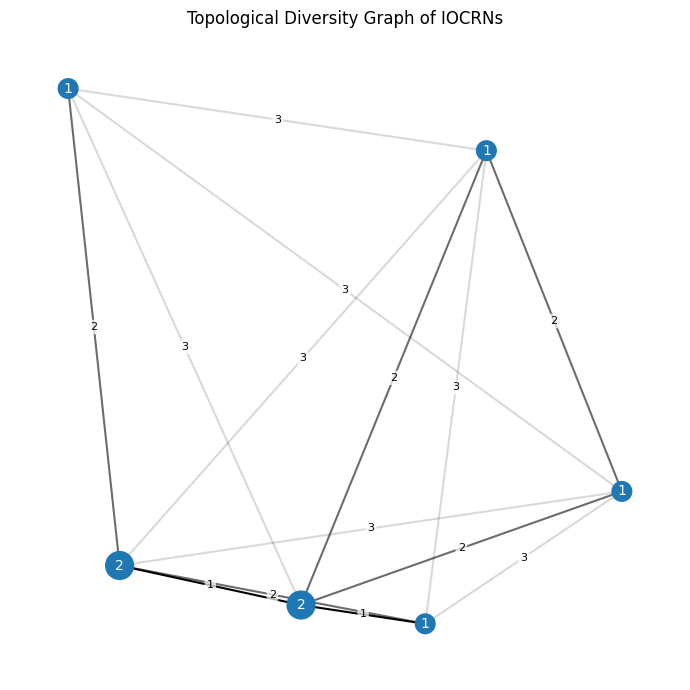

In [11]:
fig = topology_graph(iocrn_list, reaction_library, 3, figsize=(7,7))

